# 02 - Baselines: MFCC + RandomForest / SVM

This notebook reproduces the results table in the README.

The headline claim it exists to support is **negative**: on unseen cats, MFCC baselines
land at roughly the majority-class baseline. The interesting part is *why*, and what
happens to the number when you break the grouped-validation rule.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupKFold, StratifiedKFold

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
DATA_DIR = REPO_ROOT / "data" / "raw"

from features import CONTEXT_LABELS, extract_feature_matrix, scan_dataset
from train_baseline import build_models, majority_baseline

SEED = 42
N_SPLITS = 5
CLASS_ORDER = ["B", "F", "I"]
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110

assert DATA_DIR.exists(), f"{DATA_DIR} missing - run: python src/download_data.py"

## Features

Each clip becomes a 52-dim vector: mean and std of 13 MFCCs, plus mean and std of their
first temporal difference. Variable-length audio in, fixed-width vector out.

In [2]:
recordings = scan_dataset(DATA_DIR)
X, y, groups = extract_feature_matrix(recordings, kind="mfcc")

print(f"X={X.shape}  y={y.shape}  cats={len(set(groups))}")
print(f"class counts: { {CONTEXT_LABELS[c]: int((y == c).sum()) for c in CLASS_ORDER} }")
print(f"majority-class baseline: {max((y == c).mean() for c in CLASS_ORDER):.3f}")

F:\test\MeowSense\src\features.py:261: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(str(path))


X=(440, 52)  y=(440,)  cats=21
class counts: {'brushing': 127, 'food': 92, 'isolation': 221}
majority-class baseline: 0.502


## The leakage demonstration

This is the most important cell in the repository.

Below, the **same model** and the **same features** are evaluated two ways:

- **Stratified K-fold** — the standard split. A cat's clips land on both sides.
- **Group K-fold by cat** — each cat is entirely in train or entirely in test.

The gap between them is the size of the lie a random split tells you.

In [3]:
rows = []
for name in ["RandomForest (MFCC)", "SVM-RBF (MFCC)"]:
    # (a) naive: random stratified folds - cats appear in train AND test
    naive = []
    for tr, te in StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(X, y):
        m = build_models(SEED)[name]
        m.fit(X[tr], y[tr])
        naive.append(accuracy_score(y[te], m.predict(X[te])))

    # (b) honest: grouped by cat - every test cat is unseen
    grouped = []
    for tr, te in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        assert not set(groups[tr]) & set(groups[te])
        m = build_models(SEED)[name]
        m.fit(X[tr], y[tr])
        grouped.append(accuracy_score(y[te], m.predict(X[te])))

    rows.append({
        "model": name,
        "random split (LEAKY)": f"{np.mean(naive):.3f}",
        "grouped by cat (honest)": f"{np.mean(grouped):.3f} +/- {np.std(grouped):.3f}",
        "inflation": f"+{np.mean(naive) - np.mean(grouped):.3f}",
    })

pd.DataFrame(rows)

,model,random split (LEAKY),grouped by cat (honest),inflation
0,RandomForest (MFCC),0.686,0.494 +/- 0.120,+0.192
1,SVM-RBF (MFCC),0.739,0.515 +/- 0.072,+0.223


Random splits look respectable. Grouped splits collapse to roughly the baseline.

The difference is not a modelling detail — it is the entire result. A random split lets the
model recognise *which cat is meowing* (it has heard that cat before) instead of *what the
meow means*. **Every number reported in the README uses the grouped column.**

## Headline results: GroupKFold over cats

Every cat is tested exactly once. This reproduces the README table.

In [4]:
results, summary = {}, []

for name in ["RandomForest (MFCC)", "SVM-RBF (MFCC)"]:
    accs, bases, y_true, y_pred = [], [], [], []
    for tr, te in GroupKFold(n_splits=N_SPLITS).split(X, y, groups):
        m = build_models(SEED)[name]
        m.fit(X[tr], y[tr])
        p = m.predict(X[te])
        accs.append(accuracy_score(y[te], p))
        bases.append(majority_baseline(y[tr], y[te]))
        y_true.extend(y[te])
        y_pred.extend(p)

    results[name] = (np.array(y_true), np.array(y_pred))
    summary.append({
        "Model": name,
        "Accuracy (unseen cats)": f"{np.mean(accs):.2f} +/- {np.std(accs):.2f}",
        "Baseline": f"{np.mean(bases):.2f}",
        "folds": ", ".join(f"{a:.2f}" for a in accs),
    })

pd.DataFrame(summary)

,Model,Accuracy (unseen cats),Baseline,folds
0,RandomForest (MFCC),0.49 +/- 0.12,0.50,"0.27, 0.51, 0.54, 0.63, 0.52"
1,SVM-RBF (MFCC),0.52 +/- 0.07,0.50,"0.43, 0.50, 0.63, 0.47, 0.55"


## Per-class behaviour

Accuracy alone hides the interesting structure. The per-class report shows the two models
fail in the *same place*.

In [5]:
for name, (y_true, y_pred) in results.items():
    print("=" * 68)
    print(name, "- pooled over all folds")
    print("=" * 68)
    print(classification_report(
        y_true, y_pred, labels=CLASS_ORDER,
        target_names=[CONTEXT_LABELS[c] for c in CLASS_ORDER], zero_division=0,
    ))

RandomForest (MFCC) - pooled over all folds
              precision    recall  f1-score   support

    brushing       0.43      0.50      0.46       127
        food       0.33      0.38      0.36        92
   isolation       0.64      0.53      0.58       221

    accuracy                           0.49       440
   macro avg       0.47      0.47      0.47       440
weighted avg       0.51      0.49      0.50       440

SVM-RBF (MFCC) - pooled over all folds
              precision    recall  f1-score   support

    brushing       0.48      0.56      0.52       127
        food       0.21      0.22      0.21        92
   isolation       0.69      0.62      0.65       221

    accuracy                           0.52       440
   macro avg       0.46      0.46      0.46       440
weighted avg       0.53      0.52      0.52       440



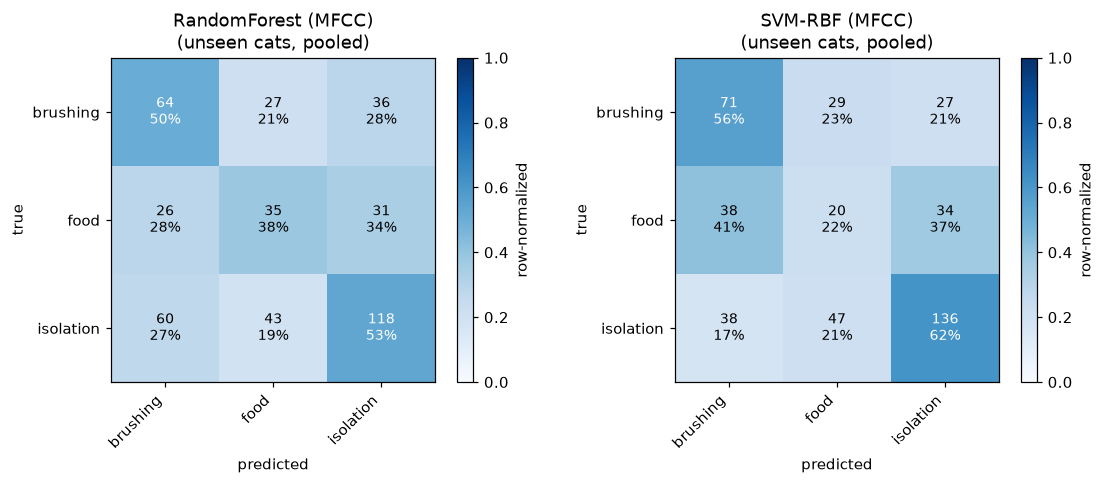

In [6]:
names = [CONTEXT_LABELS[c] for c in CLASS_ORDER]
fig, axes = plt.subplots(1, len(results), figsize=(5.2 * len(results), 4.2))

for ax, (name, (y_true, y_pred)) in zip(np.atleast_1d(axes), results.items()):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3), names, rotation=45, ha="right")
    ax.set_yticks(range(3), names)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(f"{name}\n(unseen cats, pooled)")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i, j]}\n{cm_norm[i, j]:.0%}", ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, label="row-normalized")

plt.tight_layout()

## Which cats are hard?

Per-fold accuracy varies far more than any hyperparameter choice would move it. With 4-5
cats per fold, *which* cats you hold out matters more than which model you pick — which is
the strongest possible argument that the binding constraint is data, not modelling.

In [7]:
per_fold = []
for fold, (tr, te) in enumerate(GroupKFold(n_splits=N_SPLITS).split(X, y, groups), start=1):
    m = build_models(SEED)["SVM-RBF (MFCC)"]
    m.fit(X[tr], y[tr])
    per_fold.append({
        "fold": fold,
        "test cats": len(set(groups[te])),
        "clips": len(te),
        "accuracy": round(accuracy_score(y[te], m.predict(X[te])), 3),
        "baseline": round(majority_baseline(y[tr], y[te]), 3),
    })

fold_df = pd.DataFrame(per_fold)
print(f"spread across folds: {fold_df.accuracy.min():.2f} - {fold_df.accuracy.max():.2f}")
fold_df

spread across folds: 0.43 - 0.63


,fold,test cats,clips,accuracy,baseline
0,1,4,89,0.427,0.573
1,2,4,88,0.500,0.591
2,3,5,90,0.633,0.467
3,4,4,86,0.465,0.442
4,5,4,87,0.552,0.437


## Conclusions

1. **MFCC baselines do not meaningfully beat the majority-class baseline on unseen cats.**
   Reported honestly, that is the result.
2. **`food` is the failure mode.** Both models recover it worst. "Waiting for food" is a
   fact about the situation, not a property of the sound — no acoustic model recovers it
   from audio alone. A user-supplied context signal (time since last meal) would help far
   more than a better classifier.
3. **`isolation` is the most separable class**, with the highest precision of the three. It
   is the one context with a plausible acoustic signature: distress calls are longer,
   louder and more tonal.
4. **Fold variance swamps model choice.** The gap between the best and worst fold exceeds
   the gap between RandomForest and SVM. More cats would move the number; more tuning
   would not.

See [`docs/ROADMAP.md`](../docs/ROADMAP.md) for what to do about it — transfer learning
from AudioSet-pretrained models first, then a larger crowdsourced dataset.